# 使用指数平滑（PROC ESM）预测急诊科就诊量


## 执行摘要

一家中型医院系统需要对月度急诊科（ED）就诊量进行提前一年的预测，以便在冬季呼吸道疾病激增之前规划护士人手和床位容量。本 notebook 构建了一个合成的四年月度急诊人次（48 个月，2021 年 1 月 - 2024 年 12 月），并用 **PROC ESM** 拟合一个 Winters 乘法季节模型，生成带 95% 预测区间的 12 个月预测。

拟合模型很好地刻画了该序列：样本内 **RMSE 约为 320 次就诊**，**MAPE 为 4.16%**，因此典型的月度误差不到就诊量的 5%。预测将熟悉的季节形态投射到 2025 年——12 月至 2 月的峰值接近 **7,300-7,800 次就诊/月**，夏末的低谷接近 **5,800-5,900**——预测带随着预测期延长而变宽。这些数字，以及其背后的平滑权重，都直接从下文该过程的输出数据集中读取。


## 数据来源

| 数据集 | 行数 | 粒度 | 关键变量 | 说明 |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | 每个日历月一行，2021 年 1 月 - 2024 年 12 月 | `month`（月度 SAS 日期）、`ed_visits`（整数月度急诊就诊计数） | 一家中型医院系统的合成月度急诊科就诊量。以向上的增长趋势（约每年 3%）、在冬季呼吸道疾病季（12 月至 2 月）达到峰值并在夏末回落的乘法季节周期，以及对数正态噪声生成，使季节振幅随上升的水平而缩放。 |


# 使用 PROC ESM 预测急诊科就诊量

容量规划人员需要知道每月预计有多少急诊就诊，以便排班护士、预留弹性床位，并在冬季激增之前配备呼吸道用品。急诊量是一个教科书式的季节性时间序列：它逐年缓慢增长，在 12 月至 2 月的呼吸道疾病季达到峰值，在夏末回落，而季节波动的幅度随基线量的增长而增大。这种乘法季节结构正是 **PROC ESM** 中的 Winters 乘法方法所要刻画的。

在本 notebook 中我们：

1. 生成一个真实的四年月度急诊人次，含趋势、乘法季节性和噪声。
2. 可视化该序列以确认其乘法季节结构。
3. 用 PROC ESM 拟合一个 Winters 乘法模型，并从输出数据集中读取其平滑权重和拟合统计量。
4. 生成带 95% 预测区间的提前 12 个月预测，并解读其运营含义。


## 步骤 1 - 生成合成月度急诊人次

我们构建从 2021 年 1 月到 2024 年 12 月的 48 个月度观测。每个月的预期就诊量是一个约每年增长 3% 的基线水平，乘以一个季节指数（隆冬最高，夏末最低），然后由对数正态噪声扰动，使随机变异随水平而缩放。`intnx` 每行将月对齐的日期推进一个周期，`streaminit` 使抽样可复现。


In [1]:
数据 ed_census;
    调用 streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    数组 seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    格式 month yymmn6.;
    循环 i = 1 到 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        输出;
    结束;
    保留 month ed_visits;
运行;

过程 打印 数据=ed_census(obs=14) noobs 标签;
    标签 month = '月份' ed_visits = '急诊就诊量';
    标题 '合成急诊就诊量的前 14 个月';
运行;


                                                    合成急诊就诊量的前 14 个月                                                     

    月份            急诊就诊量
202101             7103
202102             6835
202103             6668
202104             5611
202105             5816
202106             5383
202107             5586
202108             5283
202109             5161
202110             6109
202111             6451
202112             6730
202201             6847
202202             7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


最初几个月印证了设计：就诊量在 2021 年 1 月峰值时开始于接近 7,100，在春夏期间下降至其 8 月至 9 月的低谷，然后回升进入下一个冬季。到 2022 年 1 月，峰值已微升至约 6,800-7,200，反映了叠加在季节周期之上的约 3% 年增长。


## 步骤 2 - 可视化序列

在建模之前，绘制原始序列以确认我们预期的结构：一个平缓的向上趋势，每个冬季有一个重复的年度峰值，其振幅随时间变宽。逐渐变宽的季节波动是*乘法*季节过程的标志，并告诉我们该选择哪个 ESM 模型。


                                                    合成急诊就诊量的前 14 个月                                                     




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


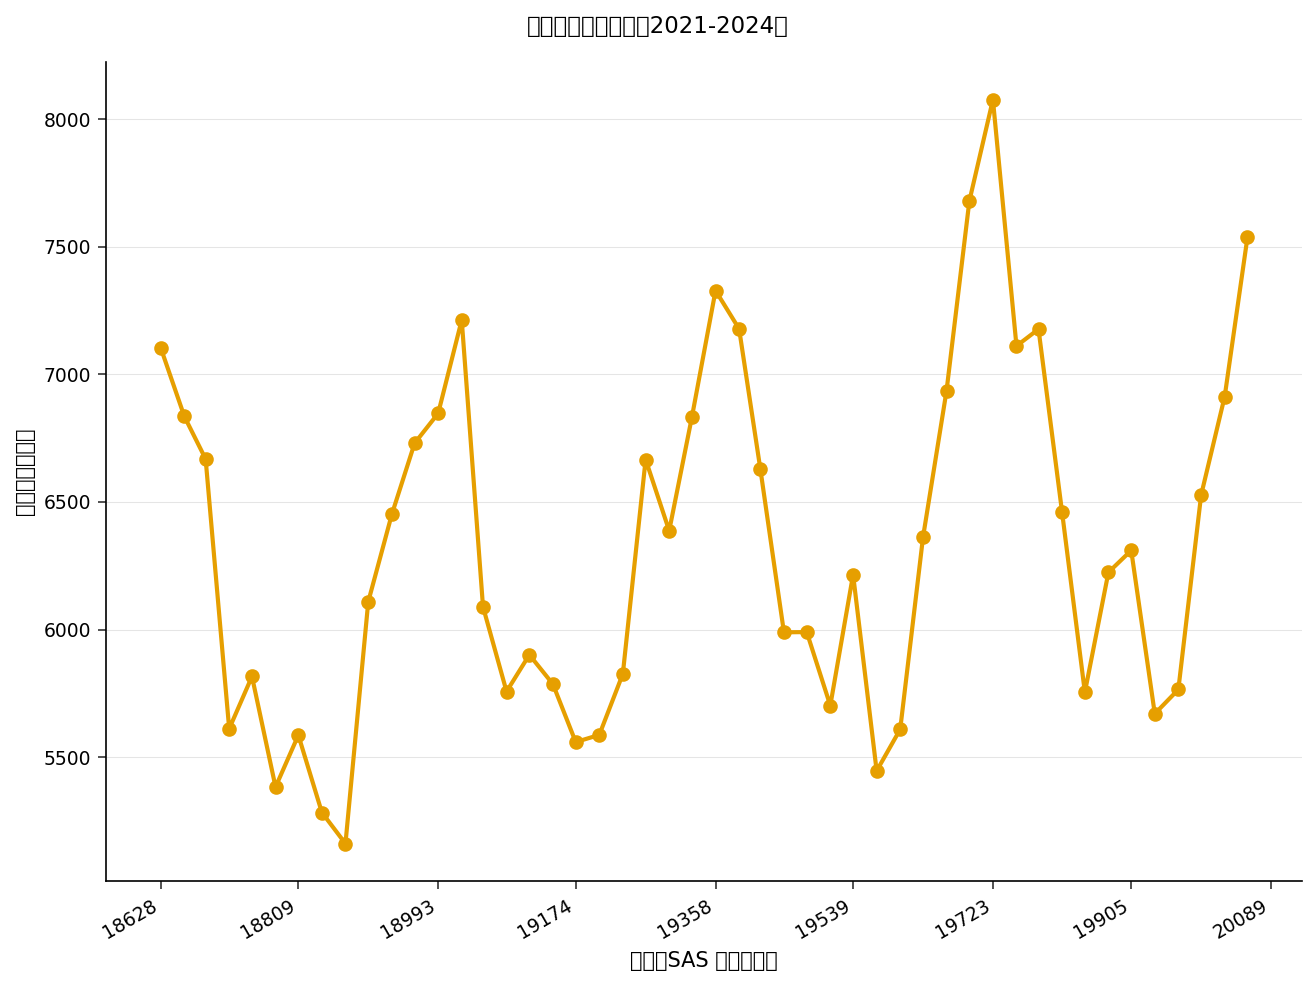

In [2]:
过程 SGPLOT 数据=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS 标签='月份（SAS 月份索引）';
    YAXIS 标签='每月急诊就诊量' grid;
    标签 month='月份' ed_visits='急诊就诊量';
    标题 '每月急诊科就诊量（2021-2024）';
运行;


该图显示了四个清晰的年度周期。每个冬季峰值都比上一个略高，从 2021 年的约 7,100 攀升至 2024 年峰值的约 8,100，而夏季低谷上升得更为温和——季节波动随水平增长。这种变宽的振幅是乘法季节性的特征，并证明下一步选用 `MODEL=WINTERS`（Winters 乘法）是合理的。


## 步骤 3 - 拟合 Winters 乘法模型

我们在完整的 48 个月历史上拟合 Winters 乘法季节平滑。`ID` 语句以 `MONTH` 间隔将 `month` 声明为时间索引，`FORECAST` 语句请求 `MODEL=WINTERS` 并设 `LEAD=12` 以向前预测一年。我们捕获三个输出数据集：

- `OUT=` - 附加了预测的历史序列（一列 `ed_visits`），时间 ID 在预测期上延伸——非常适合绘图。
- `OUTFOR=` - 每期的预测分量：点预测（`PREDICT`）和上下预测限。
- `OUTSUM=` - 模型的拟合统计量（RMSE、MAE、MAPE、AIC）和平滑权重，在单个汇总行中。

`ALPHA=0.05` 产生 95% 预测限，适合容量规划的风险余量。`PRINT=(STATISTICS)` 将拟合统计量和平滑权重回显到清单。


In [3]:
过程 esm 数据=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        打印=(statistics);
    id month interval=month;
    forecast ed_visits / 模型=winters ALPHA=0.05;
运行;

过程 打印 数据=esm_summary noobs 标签;
    标签 rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='水平 (alpha)' beta='趋势 (beta)' gamma='季节 (gamma)';
    变量 rmse mae mape ALPHA beta gamma;
    标题 'Winters 拟合统计量与平滑权重';
运行;


                                                    合成急诊就诊量的前 14 个月                                                     


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                                   Winters 拟合统计量与平滑权重                                                   

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=` 行与打印的统计量一致：Winters 乘法拟合达到样本内 **RMSE 320.4 次就诊**、**MAE 264.4** 和 **MAPE 4.16%**——典型的月度误差远低于就诊量的 5%，对人手规划而言足够准确。平滑权重为 **alpha = 0.30**（水平）、**beta = 0.10**（趋势）和 **gamma = 0.10**（季节）。中等的水平权重让基线随患者人口增长向上漂移，而较小的趋势和季节权重则反映出增长率和冬季激增形态逐年稳定，不应逐月过度反应。

> 注：这些是在估计样本上计算的*样本内*拟合统计量，而非样本外留出。它们量化模型对其拟合所依据的历史的贴合程度。


## 步骤 4 - 组装并制表 12 个月预测

`OUTFOR=` 数据集保存每一期的点预测和预测限，而 `OUT=` 数据集携带在预测期上干净延伸的时间 ID。我们按观测顺序对齐两者，将预测日期附加到预测限上，然后只保留 12 个预测月份。这些就是人手委员会将据以行动的数字。


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
数据 out_idx;
    设置 ed_with_forecast;
    row = _n_;
    重命名 month = fdate ed_visits = series_value;
运行;

数据 for_idx;
    设置 esm_forecast;
    row = _n_;
    重命名 ed_visits = observed;
    保留 row observed predict LOWER UPPER;
运行;

数据 forecast_path;
    合并 out_idx for_idx;
    按照 row;
    格式 fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
运行;

数据 forecast_horizon;
    设置 forecast_path;
    条件 observed = .;   /* forecast months only (no observed value) */
    保留 fdate predict LOWER UPPER;
运行;

过程 打印 数据=forecast_horizon noobs 标签;
    标签 fdate   = '月份'
          predict = '预测就诊量'
          LOWER   = '95% 下限'
          UPPER   = '95% 上限';
    标题 '12 个月急诊就诊量预测及 95% 预测限';
运行;


                                                 12 个月急诊就诊量预测及 95% 预测限                                                  

    月份            预测就诊量      95% 下限      95% 上限
202501            7,822       7,194       8,450
202502            7,539       6,651       8,427
202503            7,292       6,204       8,380
202504            6,263       5,007       7,519
202505            6,397       4,992       7,801
202506            6,039       4,501       7,578
202507            6,236       4,574       7,897
202508            5,867       4,091       7,644
202509            5,802       3,918       7,686
202510            6,804       4,818       8,790
202511            7,173       5,090       9,256
202512            7,567       5,391       9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


预测将季节特征向前带入 2025 年。模型预测 2025 年 1 月峰值约为 **7,822 次就诊**（95% 区间 7,194-8,450），在春季逐渐回落，在 9 月的夏末低谷触底于接近 **5,802**（区间 3,918-7,686），然后回升至约 **7,567** 的 12 月峰值（区间 5,391-9,742）。预测带随预测期稳步变宽——下个月的区间约为 +/-630 次就诊，而下一个 12 月的区间超过 +/-2,000——直接提醒我们近期计划远比年末计划更为稳固。


## 步骤 5 - 绘制历史加预测

最后，将预测叠加在观测到的历史之上，使规划人员能够看到预测的冬季峰值以及随预测期延长而变宽的不确定性带。我们将对齐的 `forecast_path` 序列拆分为**观测**历史（实线）和**12 个月预测**（虚线），使交接清晰，并在下方绘制 95% 预测带。x 轴是月度 SAS 日期索引，从左到右从 2021 年 1 月到 2025 年 12 月。


                                                 12 个月急诊就诊量预测及 95% 预测限                                                  




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


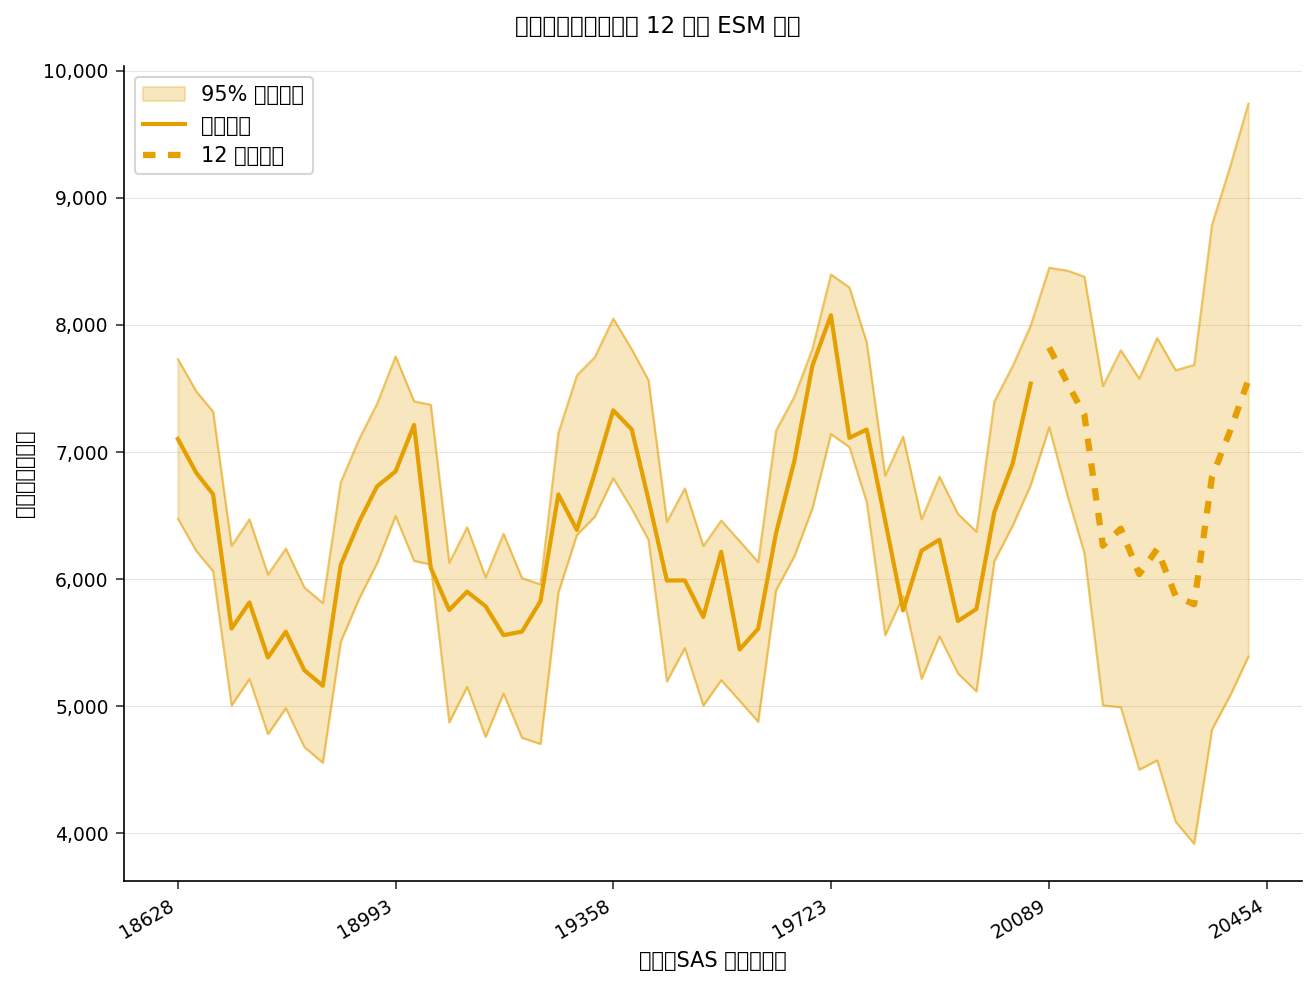

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
数据 forecast_plot;
    设置 forecast_path;
    如果 observed = . 那么 fc_only = predict;   /* future months only */
    否则 fc_only = .;
运行;

过程 SGPLOT 数据=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95% 预测区间' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='实际观测';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='12 个月预测';
    XAXIS 标签='月份（SAS 月份索引）';
    YAXIS 标签='每月急诊就诊量' grid;
    标题 '急诊就诊量：历史与 12 个月 ESM 预测';
运行;


## 结果解读

Winters 乘法模型将急诊量分解为一个缓慢上升的**水平**、一个近乎平坦的**趋势**和一个稳定的**季节**模式。从 `OUTSUM=` 读取的平滑权重讲述了这个故事：中等的水平权重（alpha = 0.30）让基线随患者人口增长向上漂移，而较小的趋势和季节权重（beta = gamma = 0.10）反映出增长率和冬季激增形态逐年高度稳定，不应逐月过度反应。

**拟合统计量**证实模型很好地贴合历史：约 320 次就诊的 RMSE 和 4.16% 的 MAPE 意味着典型的月度误差不到就诊量的 5%。在运营上，**预测表和预测带图**量化了急诊科应据以配备人手的 12 月至 2 月峰值——冬季月份约 7,300-7,800 次就诊——而 95% 预测限界定了一个审慎的容量范围：按点预测规划核心人手，并朝上限预先安排弹性覆盖和激增床位。区间随预测期变宽，因此下个月的计划远比下一个 12 月的更为稳固，应随新的实际值到来而刷新。

**扩展：** 将 `MODEL=ADDWINTERS`（加法季节性）与乘法拟合进行比较，以确认乘法选择；应用 `TRANSFORM=LOG` 以强制正性并稳定方差；或添加 `BY` 语句以在单次 PROC ESM 调用中预测多个医院站点。
